<a href="https://colab.research.google.com/github/iannickgagnon/sagedays_iannick_2026/blob/main/python_2/carnet_python_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Slide no.3 - Tests: Assertions

In [ ]:
valeur_1: int = int(input('Saisir un entier: '))
valeur_2: int = int(input('Saisir un entier différent: '))
assert valeur_1 != valeur_2, 'Les valeurs doivent être différentes'
print('Les valeurs sont différentes')

# Slide no.4 - EXERCICE: Assertion d'égalité

In [ ]:
from typing import Union

def assert_equal(x_obtenu: Union[int, float],
                 x_cible: Union[int, float],
                 tolerance: float = 1e-6) -> None:
  """
  Effectue un test d'égalité basé sur une tolérance.

  Args:
    x_obtenu (Union[int, float]): La valeur à tester.
    x_cible (Union[int, float]): La valeur cible.
    tolerance (Union[int, float]): La tolérance numérique.

  Retourne:
    Rien.
  """
  assert abs(x_obtenu - x_cible) <= tolerance, 'Les valeurs ne sont pas égales'

In [ ]:
assert_equal(1, 1 + 1e-7)
print('Pas mort!')

assert_equal(1, 1 + 1e-6)
print('Pas mort!')

assert_equal(1, 1 + 1e-5)

# Slide no.5 - Tests: Librairie Pytest

In [ ]:
import pytest

liste_1 = [1, 2, 3, 4, 5]

# Copier la liste et ajouter 10e-6 au premier élément
liste_2 = liste_1.copy()
liste_2[0] += 1e-6

# Ceci est vrai
assert liste_1 == pytest.approx(liste_2), 'Erreur (epsilon = 1e-6)'

# Changer la tolérange pour déclencher une erreur
assert liste_1 == pytest.approx(liste_2, abs=1e-7), 'Erreur (epsilon = 1e-7)'

# Slide no.6 - Exceptions

In [ ]:
try:
  raise ValueError("J'ai lancé la ValueError!")
except ValueError as err:
  raise ValueError("J'ai attrapé la ValueError!") from err
print('Ce message ne sera pas affiché')

# Slide no.7 - Gestion d'exceptions

In [ ]:
def calculer_afficher_racines(a, b, c):
  """
  Calcule et affiche les racines d'une quadratique.

  Arguments:
    a (int): Coefficient du terme x^2.
    b (int): Coefficient du terme x^1.
    c (int): Coefficient du terme x^0.

  Retourne:
    Rien.
  """

  # Valider que le coeficient 'a' n'est pas nul
  """
  ÉCRIVEZ VOTRE CODE ICI
  """
  if a == 0:
    raise ValueError("Le coefficient 'a' ne peut pas être nul")

  # Calcul des racines
  racine_discriminant = (b**2 - 4 * a * c)**0.5
  r1 = (-b - racine_discriminant) / (2 * a)
  r2 = (-b + racine_discriminant) / (2 * a)

  # Affichage
  print(r1, r2)

In [ ]:
def main():
  try:
    calculer_afficher_racines(a=0, b=2, c=-1)
  except ValueError as err:
    raise RuntimeError('Une erreur innatendue est survenue!') from errb

main()

# Slide no.8 - Une toute petite classe

In [ ]:
class TresGrosseErreur(Exception):
  """
  Erreur à lever lorsque Iannick écrit du code.
  """
  pass

In [ ]:
raise TresGrosseErreur('Oops!')

# Slide no.9-10 - Une classe-contenant

In [ ]:
from dataclasses import dataclass

@dataclass
class Vecteur:
  """
  Un vecteur en 1, 2 ou 3 dimensions.

  Attributs:
    dx (float): Le composant en x du vecteur. Valeur par défaut de 0.0.
    dy (float): Le composant en y du vecteur. Valeur par défaut de 0.0.
    dz (float): Le composant en z du vecteur. Valeur par défaut de 0.0.
  """
  dx: float = 0.0
  dy: float = 0.0
  dz: float = 0.0

  def calculer_norme(self) -> float:
    """
    Calcule la norme Euclidienne du vecteur.

    Args:
      Aucuns.

    Retourne:
      float: La norme du vecteur.
    """
    return (self.dx ** 2 +
            self.dy ** 2 +
            self.dz ** 2) ** 0.5


In [ ]:
un_vecteur = Vecteur(dx=1.0, dy=2.0)
print(un_vecteur)

In [ ]:
print(f'La norme vaut {un_vecteur.calculer_norme()}')

# Slide no.11 - EXERCICE: Vecteur direction

In [ ]:
from __future__ import annotations

from dataclasses import dataclass
from pytest import approx


class NullNormError(Exception):
  """
  Erreur levée lorsqu'un calcul nécessite une norme positive.
  """
  pass


@dataclass
class Vecteur:
  """
  Un vecteur en 1, 2 ou 3 dimensions.

  Attributs:
    dx (float): Le composant en x du vecteur. Valeur par défaut de 0.0.
    dy (float): Le composant en y du vecteur. Valeur par défaut de 0.0.
    dz (float): Le composant en z du vecteur. Valeur par défaut de 0.0.
  """
  dx: float = 0.0
  dy: float = 0.0
  dz: float = 0.0

  def calculer_norme(self) -> float:
    """
    Calcule la norme Euclidienne du vecteur.

    Args:
      Aucuns.

    Retourne:
      float: La norme du vecteur.
    """
    return (self.dx ** 2 +
            self.dy ** 2 +
            self.dz ** 2) ** 0.5

  def calculer_vecteur_direction(self) -> Vecteur:
    """
    Calcule le vecteur direction correspondant.

    Args:
      Aucuns.

    Retourne:
      Vecteur: Le vecteur direction.

    Raises:
      NullNormError: Si la norme du vecteur est nulle.
    """

    # Calculer la norme du vecteur
    norme: float = self.calculer_norme()

    # Valider que la norme n'est pas nulle
    if norme == approx(0):
      raise NullNormError('La norme ne peut être nulle')

    # Composant du vecteur direction
    dx_direction: float = self.dx / norme
    dy_direction: float = self.dy / norme
    dz_direction: float = self.dz / norme

    # Instancier le vecteur direction
    vecteur_direction: Vecteur = Vecteur(dx=dx_direction,
                                         dy=dy_direction,
                                         dz=dz_direction)

    return vecteur_direction

In [ ]:
# Ceci devrait déclencher une NullNormError
Vecteur(1e-13).calculer_vecteur_direction()

In [ ]:
# Ceci devrait donner <1/racine(3), 1/racine(3), 1/racine(3)>
vecteur = Vecteur(1, 1, 1)
print(f"Vecteur = {vecteur}")
vecteur_direction = vecteur.calculer_vecteur_direction()
print(f"Vecteur direction = {vecteur_direction}")

# Slide no.12-13: Sérialisation en fichier texte (.txt)

In [ ]:
from __future__ import annotations

from dataclasses import dataclass
from pytest import approx


class NullNormError(Exception):
  """
  Erreur levée lorsqu'un calcul nécessite une norme positive.
  """
  pass


@dataclass
class Vecteur:
  """
  Un vecteur en 1, 2 ou 3 dimensions.

  Attributs:
    dx (float): Le composant en x du vecteur. Valeur par défaut de 0.0.
    dy (float): Le composant en y du vecteur. Valeur par défaut de 0.0.
    dz (float): Le composant en z du vecteur. Valeur par défaut de 0.0.
  """
  dx: float = 0.0
  dy: float = 0.0
  dz: float = 0.0

  def calculer_norme(self) -> float:
    """
    Calcule la norme Euclidienne du vecteur.

    Args:
      Aucuns.

    Retourne:
      float: La norme du vecteur.
    """
    return (self.dx ** 2 +
            self.dy ** 2 +
            self.dz ** 2) ** 0.5

  def calculer_vecteur_direction(self) -> Vecteur:
    """
    Calcule le vecteur direction correspondant.

    Args:
      Aucuns.

    Retourne:
      Vecteur: Le vecteur direction.

    Raises:
      NullNormError: Si la norme du vecteur est nulle.
    """

    # Calculer la norme du vecteur
    norme: float = self.calculer_norme()

    # Valider que la norme n'est pas nulle
    if norme == approx(0):
      raise NullNormError('La norme ne peut être nulle')

    # Composant du vecteur direction
    dx_direction: float = self.dx / norme
    dy_direction: float = self.dy / norme
    dz_direction: float = self.dz / norme

    # Instancier le vecteur direction
    vecteur_direction: Vecteur = Vecteur(dx=dx_direction,
                                         dy=dy_direction,
                                         dz=dz_direction)

    return vecteur_direction

  def sauvegarder_txt(self, nom_fichier: txt) -> None:


# Slide no.14 - Écrire dans un fichier

In [ ]:
with open('fichier.txt', mode='w') as fichier:
  for i in range(5):
    fichier.write(f'Ligne no.{i + 1}: bla-bla\n')

# Slide no. 15 - Lire un fichier

In [ ]:
with open('fichier.txt', mode='r') as fichier:
  texte: list[str] = fichier.readlines()

for ligne in texte:
  print(ligne)

# Slide no.16 - EXERCICE: Vecteur sérialisé

In [ ]:
from __future__ import annotations

from dataclasses import dataclass
from pytest import approx


class NullNormError(Exception):
  """
  Erreur levée lorsqu'un calcul nécessite une norme positive.
  """
  pass


@dataclass
class Vecteur:
  """
  Un vecteur en 1, 2 ou 3 dimensions.

  Attributs:
    dx (float): Le composant en x du vecteur. Valeur par défaut de 0.0.
    dy (float): Le composant en y du vecteur. Valeur par défaut de 0.0.
    dz (float): Le composant en z du vecteur. Valeur par défaut de 0.0.
  """
  dx: float = 0.0
  dy: float = 0.0
  dz: float = 0.0

  def calculer_norme(self) -> float:
    """
    Calcule la norme Euclidienne du vecteur.

    Args:
      Aucuns.

    Retourne:
      float: La norme du vecteur.
    """
    return (self.dx ** 2 +
            self.dy ** 2 +
            self.dz ** 2) ** 0.5

  def calculer_vecteur_direction(self) -> Vecteur:
    """
    Calcule le vecteur direction correspondant.

    Args:
      Aucuns.

    Retourne:
      Vecteur: Le vecteur direction.

    Raises:
      NullNormError: Si la norme du vecteur est nulle.
    """

    # Calculer la norme du vecteur
    norme: float = self.calculer_norme()

    # Valider que la norme n'est pas nulle
    if norme == approx(0):
      raise NullNormError('La norme ne peut être nulle')

    # Composant du vecteur direction
    dx_direction: float = self.dx / norme
    dy_direction: float = self.dy / norme
    dz_direction: float = self.dz / norme

    # Instancier le vecteur direction
    vecteur_direction: Vecteur = Vecteur(dx=dx_direction,
                                         dy=dy_direction,
                                         dz=dz_direction)

    return vecteur_direction

  def sauvegarder_txt(self, nom_fichier: str) -> None:
    """
    Sérialise le contenu du vecteur dans un fichier texte.

    Args:
      nom_fichier (str): Le nom du fichier de sauvegarde.

    Retourne:
      Rien.
    """
    # Ouvrir le fichier texte en mode écriture
    with open(nom_fichier, mode='w') as fichier:
      fichier.write(f'{self.dx}\n')
      fichier.write(f'{self.dy}\n')
      fichier.write(f'{self.dz}\n')

  def charger_txt(self, nom_fichier: str) -> None:
    """
    Charge les composants du vecteur à partir d'un fichier texte.

    Args:
      nom_fichier (str): Le nom du fichier texte.

    Retourne:
      Rien.
    """

    # Lire le contenu du fichier texte en mode lecture
    with open(nom_fichier, mode='r') as fichier:
      texte: list[str] = fichier.readlines()

    # Valider qu'il y a le bon nombre de composants
    if len(texte) != 3:
      raise ValueError(f'Il doit y avoir exactement 3 composants plutôt que {len(texte)}')

    # Transformer composants en float et stocker
    self.dx = float(texte[0])
    self.dy = float(texte[1])
    self.dz = float(texte[2])

In [ ]:
# Initialiser le vecteur 1 et l'afficher
vecteur_1 = Vecteur(1, 2, 3)
print(f'vecteur_1 = {vecteur_1}')

# Initialiser le vecteur 2 et l'afficher
vecteur_2 = Vecteur()
print('\nAVANT CHARGEMENT')
print(f'vecteur_2 = {vecteur_2}')

# Charger le contenu du vecteur 1 dans le vecteur 2
vecteur_1.sauvegarder_txt('vecteur.txt')
vecteur_2.charger_txt('vecteur.txt')
print('\nAPRÈS CHARGEMENT')
print(f'vecteur_2 = {vecteur_2}')

# Slide no.17-21 - Introduction aux graphiques

In [ ]:
# Importer l'interface pytplot de la librairie matplotlib
import matplotlib.pyplot as plt

# Fonction cosinus
from math import cos

In [ ]:
# Créer les données à tracer
x: list[float] = [0.1 * i for i in range(65)]
y: list[float] = [cos(5 * valeur) for valeur in x]

# Créer le graphique
plt.plot(x, y)

# L'afficher
plt.show()

# Slide no.22 - EXERCICE: Tracer des vecteurs

In [ ]:
from dataclasses import dataclass
from math import sqrt
import matplotlib.pyplot as plt
from pytest import approx


class NullNormError(Exception):
  """
  Erreur levée lorsqu'un calcul nécessite une norme positive.
  """
  pass


@dataclass
class Vecteur:
  """
  Un vecteur en 1, 2 ou 3 dimensions.

  Attributs:
    dx (float): Le composant en x du vecteur. Valeur par défaut de 0.0.
    dy (float): Le composant en y du vecteur. Valeur par défaut de 0.0.
    dz (float): Le composant en z du vecteur. Valeur par défaut de 0.0.
  """
  dx: float = 0.0
  dy: float = 0.0
  dz: float = 0.0

  def calculer_norme(self) -> float:
    """
    Calcule la norme Euclidienne du vecteur.

    Args:
      Aucuns.

    Retourne:
      float: La norme du vecteur.
    """
    return (self.dx ** 2 +
            self.dy ** 2 +
            self.dz ** 2) ** 0.5

  def calculer_vecteur_direction(self) -> Vecteur:
    """
    Calcule le vecteur direction correspondant.

    Args:
      Aucuns.

    Retourne:
      Vecteur: Le vecteur direction.

    Raises:
      NullNormError: Si la norme du vecteur est nulle.
    """

    # Calculer la norme du vecteur
    norme: float = self.calculer_norme()

    # Valider que la norme n'est pas nulle
    if norme == approx(0):
      raise NullNormError('La norme ne peut être nulle')

    # Composant du vecteur direction
    dx_direction: float = self.dx / norme
    dy_direction: float = self.dy / norme
    dz_direction: float = self.dz / norme

    # Instancier le vecteur direction
    vecteur_direction: Vecteur = Vecteur(dx=dx_direction,
                                         dy=dy_direction,
                                         dz=dz_direction)

    return vecteur_direction

  def sauvegarder_txt(self, nom_fichier: str) -> None:
    """
    Sérialise le contenu du vecteur dans un fichier texte.

    Args:
      nom_fichier (str): Le nom du fichier de sauvegarde.

    Retourne:
      Rien.
    """
    # Ouvrir le fichier texte en mode écriture
    with open(nom_fichier, mode='w') as fichier:
      fichier.write(f'{self.dx}\n')
      fichier.write(f'{self.dy}\n')
      fichier.write(f'{self.dz}\n')

  def charger_txt(self, nom_fichier: str) -> None:
    """
    Charge les composants du vecteur à partir d'un fichier texte.

    Args:
      nom_fichier (str): Le nom du fichier texte.

    Retourne:
      Rien.
    """

    # Lire le contenu du fichier texte en mode lecture
    with open(nom_fichier, mode='r') as fichier:
      texte: list[str] = fichier.readlines()

    # Valider qu'il y a le bon nombre de composants
    if len(texte) != 3:
      raise ValueError(f'Il doit y avoir exactement 3 composants plutôt que {len(texte)}')

    # Transformer composants en float et stocker
    self.dx = float(texte[0])
    self.dy = float(texte[1])
    self.dz = float(texte[2])

  def _calculer_coordonnees_fleche(self, fraction: float = 0.1) -> dict:
    """
    Calcule les coordonnées des extrémités des pointes de la tête du vecteur.

    Args:
      fraction (float, optionnel): La longueur du côté de la tête par rapport à la longueur du vecteur.
        Valeur par défaut de 0.1 (10%).

    Retourne:
      Un dictionnaire contenant:
        - 'xb' (float): La coordonnée en x de du premier côté.
        - 'yb' (float): La coordonnée en y de du premier côté.
        - 'xc' (float): La coordonnée en x de du deuxième côté.
        - 'yc' (float): La coordonnée en y de du deuxième côté.
    """

    # Pour éviter de calculer plusieurs fois
    _sqrt_2: float = sqrt(2)
    _dx_plus_dy: float = self.dx + self.dy

    # Calculer la norme du vecteur
    norme: float = self.calculer_norme()

    # Calculer la cordonnée de la première pointe
    xb: float = self.dx - fraction * (_dx_plus_dy) / (_sqrt_2 * norme)
    yb: float = self.dy + fraction * (self.dx - self.dy) / (_sqrt_2 * norme)

    # Calculer la coordonnée de la deuxième pointe
    xc: float = self.dx + fraction * (self.dy - self.dx) / (_sqrt_2 * norme)
    yc: float = self.dy - fraction * (_dx_plus_dy) / (_sqrt_2 * norme)

    return {'xb': xb,
            'yb': yb,
            'xc': xc,
            'yc': yc}

  def tracer_xy(self, fraction: float = 0.1) -> None:
    """
    Trace une représentation graphique du vecteur dans le plan Oxy.

    Args:
      fraction (float, optionnel): La longueur du côté de la tête par rapport à la longueur du vecteur.
        Valeur par défaut de 0.1 (10%).

    Retourne:
      Rien.
    """

    # Calculer les coordonées de la tête
    coordonnees_pointes: dict = self._calculer_coordonnees_fleche(fraction=fraction)

    # Extraire les coordonées
    xb, yb, xc, yc = coordonnees_pointes.values()

    # Tracer le corps du vecteur
    plt.plot([0, self.dx], [0, self.dy], color='k')

    # Tracer la tête du vecteur
    plt.plot([xb, self.dx], [yb, self.dy], color='k')
    plt.plot([xc, self.dx], [yc, self.dy], color='k')

    # Égaliser les axes
    plt.axis('equal')

    # Afficher le graphe
    plt.show()


In [ ]:
# Initialiser un vecteur
vecteur = Vecteur(1, 1)

# Tracé par défaut
vecteur.tracer_xy()

# Espace entre les deux vecteurs
print()

# Tracé avec tête allongée
vecteur.tracer_xy(fraction=0.25)

# Slide no.24 - Temps d'exécution (1/3)


```python
from time import perf_counter

debut: float = perf_counter()

# Le code à mesurer

fin: float = perf_counter()

# Calculer et afficher la durée
duree: float = fin - debut
print(f"Temps d'exécution: {duree} s")
```

In [ ]:
from time import perf_counter

def generer_liste_carres_1(n: int) -> list[int]:
  """
  Crée une liste des n permiers carrés par ajouts successifs avec list.apppend().
  """
  carres: list[int] = []
  for i in range(n):
    carres.append(i ** 2)
  return carres

def generer_liste_carres_2(n: int) -> list[int]:
  """
  Crée une liste des n premiers carrés par compréhension.
  """
  return [i ** 2 for i in range(n)]

# Première méthode
debut = perf_counter()
generer_liste_carres_1(10_000_000)
fin = perf_counter()
print(f'Version 1: {fin - debut} s')

# Deuxième méthode
debut = perf_counter()
generer_liste_carres_2(10_000_000)
fin = perf_counter()
print(f'Version 2: {fin - debut} s')

# Slide no.25 - Temps d'exécution (2/3)

## Expressions lambda: `lambda [paramètres]: expression`

In [ ]:
# Calcule la puissance d'une base donnée
foo_puissance = lambda base, puissance: base ** puissance
print(f'2^8 = {foo_puissance(2, 8)}')

# Saut de ligne
print()

# Transforme une liste en dictionnaire de format {'valeur_1': liste[0], ..., 'valeur_n': liste[n - 1]}
foo_liste_vers_dico = lambda liste: {f'valeur_{i + 1}': valeur for i, valeur in enumerate(liste)}
print(foo_liste_vers_dico([foo_puissance(2, i) for i in range(9)]))

## Exemple: Temps moyen (n = 3)

In [ ]:
import timeit
from random import randint
from statistics import mean

def generer_liste_carres_1(n: int) -> list[int]:
  """
  Crée une liste des n permiers carrés par ajouts successifs avec list.apppend().
  """
  carres: list[int] = []
  for i in range(n):
    carres.append(i ** 2)
  return carres

def generer_liste_carres_2(n: int) -> list[int]:
  """
  Crée une liste des n premiers carrés par compréhension.
  """
  return [i ** 2 for i in range(n)]

# Nous allons calculer la moyenne de 10 essais

temps_1 = timeit.repeat(lambda: generer_liste_carres_1(10_000_000), number=1, repeat=3)
temps_2 = timeit.repeat(lambda: generer_liste_carres_2(10_000_000), number=1, repeat=3)

moyenne_temps_1 = mean(temps_1)
moyenne_temps_2 = mean(temps_2)

print(f"Version 1 : {moyenne_temps_1} s")
print(f"Version 2 : {moyenne_temps_2} s")

# Slide no.26 - Temps d'exécution (3/3)

In [ ]:
!pip install perfplot

Output()

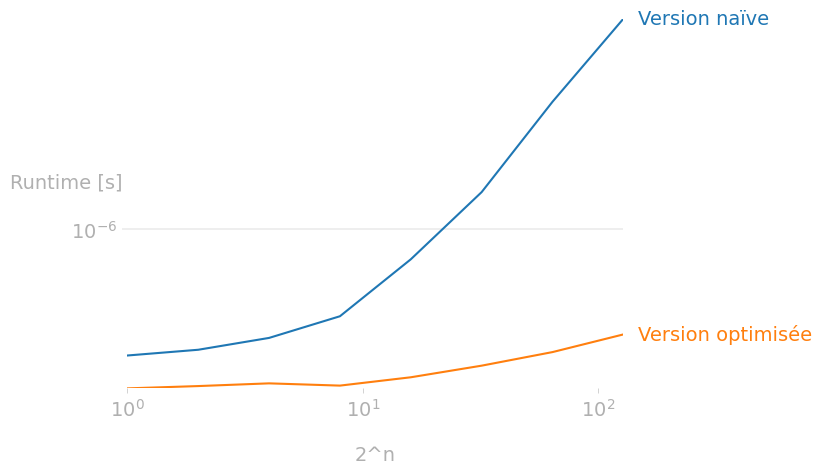

In [11]:
import perfplot
from random import randint

def calculer_puissance_1(base: int, puissance: int) -> int:
  """
  Calcule la puissance d'une base donnée par multiplications successives.
  """
  resultat: int = 1
  for _ in range(puissance):
    resultat *= base
  return resultat

def calculer_puissance_2(base: int, puissance: int) -> int:
    """
    Calcule la base d'une puissance donnée avec l'opérateur natif puissance (int.__pow__()).
    """
    return base ** puissance

perfplot.show(

    # Transformation appliquée sur la taille d'entrée: Aucune (n -> n)
    setup=lambda n: n,

    # Liste de fonctions à tester en fonction de la taille d'entrée
    kernels=[
        lambda n: calculer_puissance_1(2, n),
        lambda n: calculer_puissance_2(2, n),
    ],

    # Étiquettes pour les différentes méthodes 'kernels' ci-dessus
    labels=[
        "Version naïve",
        "Version optimisée",
    ],

    # Les valeur de tailles d'entrées à tester (n)
    n_range=[2 ** i for i in range(8)],

    # L'étiquette de l'axe horizontal (x)
    xlabel="2^n",

    # Vérifier que les valeurs retournées sont pareilles (c.-à-d. comparer des pommes avec des pommes)
    equality_check=lambda x, y: x == y,

)

# Slide no.27-28 - Formats CSV, JSON et YAML (si le temps le permet)


## Exemple: Fichier CSV

In [20]:
import csv

with open("fichier.csv") as fichier:

    # Instancier le lecteur à partir du fichier
    lecteur = csv.reader(fichier)

    # Stocker son contenu dans des listes
    lignes = list(lecteur)

    # Afficher le contenu de chaque ligne
    for ligne in lignes:
        print(ligne)

    # Convertir les valeurs en rationnels
    for i in range(len(lignes)):
      lignes[i] = [float(valeur) for valeur in lignes[i]]
      print(lignes[i])

['1', '2', '3', '4', '5']
[1.0, 2.0, 3.0, 4.0, 5.0]


## Exemple: Fichier JSON

In [21]:
import json

# Lire le fichier
with open("fichier.json") as fichier:
    contenu = json.load(fichier)

# Explorer la structure en dictionnaire résultante
print(contenu)
print(contenu["vecteur"])
print(f'dx = {contenu["vecteur"]["dx"]}')
print(f'dy = {contenu["vecteur"]["dy"]}')
print(f'norme = {contenu["vecteur"]["norme"]}')

{'vecteur': {'dx': 3, 'dy': 4, 'norme': 5}}
{'dx': 3, 'dy': 4, 'norme': 5}
dx = 3
dy = 4
norme = 5


## Exemple: Fichier YAML

In [23]:
import yaml

# Lire le fichier
with open("fichier.yaml") as fichier:
    contenu = yaml.safe_load(fichier)

# Explorer la structure en dictionnaire résultante
print(contenu)
print(contenu["options"])
print(f'option.number = {contenu["options"]["number"]}')
print(f'option.repeat = {contenu["options"]["repeat"]}')

{'options': {'number': 1, 'repeat': 3}}
{'number': 1, 'repeat': 3}
option.number = 1
option.repeat = 3
